# The Product Pricer Continued

A model that can estimate how much something costs, from its description.

## AT LAST - it's time for Fine Tuning!

After all this data preparation, and old school machine learning, we've finally arrived at the moment you've been waiting for. Fine-tuning a model.

In [2]:
# imports

import os
import re
import math
import json
import random
from dotenv import load_dotenv
from huggingface_hub import login
import matplotlib.pyplot as plt
import numpy as np
import pickle
from collections import Counter
from openai import OpenAI
from anthropic import Anthropic

In [3]:
# environment

load_dotenv(override=True)
os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY', '####-####-####-####')
os.environ['HF_TOKEN'] = os.getenv('HF_TOKEN', '####-####-####-####')

In [4]:
# Log in to HuggingFace

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


In [5]:
# moved our Tester into a separate package
# call it with Tester.test(function_name, test_dataset)

from items import Item
from testing import Tester

In [6]:
openai = OpenAI()

In [7]:
%matplotlib inline

In [8]:
# Let's avoid curating all our data again! Load in the pickle files:

with open('train.pkl', 'rb') as file:
    train = pickle.load(file)

with open('test.pkl', 'rb') as file:
    test = pickle.load(file)

In [9]:
# OpenAI recommends fine-tuning with populations of 50-100 examples
# But as our examples are very small, I'm suggesting we go with 200 examples (and 1 epoch)

fine_tune_train = train[:200]
fine_tune_validation = train[200:250]

In [10]:
item = train[0]
print("Item attributes:")
print(f"- title: {item.title}")
print(f"- price: {item.price}")
print(f"- category: {item.category}")
print(f"- token_count: {item.token_count}")
print(f"- prompt: {item.prompt}")
print(f"- details: {item.details}")

print("----------------------------------------------------------------------------------------------------------------")

item = test[0]
print("Item attributes:")
print(f"- title: {item.title}")
print(f"- price: {item.price}")
print(f"- category: {item.category}")
print(f"- token_count: {item.token_count}")
print(f"- prompt: {item.prompt}")
print(f"- details: {item.details}")

Item attributes:
- title: Gefu Coffee Filter Sandro, Size 4, Accessories, Porcelain, Prolonged Outlet, 16020
- price: 38.66
- category: Appliances
- token_count: 177
- prompt: How much does this cost to the nearest dollar?

Gefu Coffee Filter Sandro, Size 4, Accessories, Porcelain, Prolonged Outlet, 16020
With the porcelain coffee filter, hand-brewed coffee is a pleasure, not only for nostalgics. Simply pour some water over the ground coffee so that it swells and the flavours dissolve. Then fill the filter to the brim and wait until the coffee has run through completely. Repeat this process until the cup or jug ​​is full, and then. Enjoy The extended socket ensures optimum hold on almost every vacuum jug. For filters standard size separately) Dimensions H 145,? 130?mm Dishwasher-safe Product guaranteed for Dimensions 6.42 x 6.22 x 6.38 inches, Weight 1.41 pounds, Manufacturer G

Price is $39.00
- details: {"Product Dimensions": "6.42 x 6.22 x 6.38 inches", "Item Weight": "1.41 pounds",

In [11]:
!cat items.py

from typing import Optional
from transformers import AutoTokenizer
import re

BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"

MIN_TOKENS = 150 # Any less than this, and we don't have enough useful content
MAX_TOKENS = 160 # Truncate after this many tokens. Then after adding in prompt text, we will get to around 180 tokens

MIN_CHARS = 300
CEILING_CHARS = MAX_TOKENS * 7

class Item:
    """
    An Item is a cleaned, curated datapoint of a Product with a Price
    """
    
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
    PREFIX = "Price is $"
    QUESTION = "How much does this cost to the nearest dollar?"
    REMOVALS = ['"Batteries Included?": "No"', '"Batteries Included?": "Yes"', '"Batteries Required?": "No"', '"Batteries Required?": "Yes"', "By Manufacturer", "Item", "Date First", "Package", ":", "Number of", "Best Sellers", "Number", "Product "]

    title: str
    price: float
    category: str
    token_count: int = 0
    details: Optional[str]
  

In [12]:
#print(fine_tune_train[1].prompt)
print(fine_tune_validation[1].prompt)

How much does this cost to the nearest dollar?

Appliance Parts GT6 Range Trim Ring
Product Description Chrome plated Range Trim Ring For GE & Hotpoint. Range Trim Ring. 6 TRIM RING CHROME PLATED. (FOR GE HP From the Manufacturer Chrome plated Range Trim Ring For GE & Hotpoint. Range Trim Ring. 6 TRIM RING CHROME PLATED. (FOR GE HP Range Trim Ring 6 Trim Ring Chrome Plated (For Ge Hp From The Brand Appliance Parts Manufacturer American Standard, Part GT6, Weight 0.353 ounces, Dimensions 1 x 2 x 3 inches, Country of Origin USA, model number GT6, Is Discontinued No, Quantity 1, Rank Tools & Home Improvement Range Replacement Burner Rings 112, Domestic Shipping can be shipped within U.S

Price is $8.00


# Step 1

Prepare our data for fine-tuning in JSONL (JSON Lines) format and upload to OpenAI

In [13]:
# First let's work on a good prompt for a Frontier model
# Notice that I'm removing the " to the nearest dollar"
# When we train our own models, we'll need to make the problem as easy as possible,
# but a Frontier model needs no such simplification.

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": f"Price is ${item.price:.2f}"}
    ]

In [14]:
messages_for(train[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nGefu Coffee Filter Sandro, Size 4, Accessories, Porcelain, Prolonged Outlet, 16020\nWith the porcelain coffee filter, hand-brewed coffee is a pleasure, not only for nostalgics. Simply pour some water over the ground coffee so that it swells and the flavours dissolve. Then fill the filter to the brim and wait until the coffee has run through completely. Repeat this process until the cup or jug \u200b\u200bis full, and then. Enjoy The extended socket ensures optimum hold on almost every vacuum jug. For filters standard size separately) Dimensions H 145,? 130?mm Dishwasher-safe Product guaranteed for Dimensions 6.42 x 6.22 x 6.38 inches, Weight 1.41 pounds, Manufacturer G'},
 {'role': 'assistant', 'content': 'Price is $38.66'}]

In [15]:
# Convert the items into a list of json objects - a "jsonl" string
# Each row represents a message in the form:
# {"messages" : [{"role": "system", "content": "You estimate prices...


def make_jsonl(items):
    result = ""
    for item in items:
        messages = messages_for(item)
        messages_str = json.dumps(messages)
        result += '{"messages": ' + messages_str +'}\n'
    return result.strip()

In [16]:
print(make_jsonl(train[:3]))

{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only with the price, no explanation"}, {"role": "user", "content": "How much does this cost?\n\nGefu Coffee Filter Sandro, Size 4, Accessories, Porcelain, Prolonged Outlet, 16020\nWith the porcelain coffee filter, hand-brewed coffee is a pleasure, not only for nostalgics. Simply pour some water over the ground coffee so that it swells and the flavours dissolve. Then fill the filter to the brim and wait until the coffee has run through completely. Repeat this process until the cup or jug \u200b\u200bis full, and then. Enjoy The extended socket ensures optimum hold on almost every vacuum jug. For filters standard size separately) Dimensions H 145,? 130?mm Dishwasher-safe Product guaranteed for Dimensions 6.42 x 6.22 x 6.38 inches, Weight 1.41 pounds, Manufacturer G"}, {"role": "assistant", "content": "Price is $38.66"}]}
{"messages": [{"role": "system", "content": "You estimate prices of items. Reply only wi

In [17]:
# Convert the items into jsonl and write them to a file

def write_jsonl(items, filename):
    with open(filename, "w") as f:
        jsonl = make_jsonl(items)
        f.write(jsonl)

In [18]:
write_jsonl(fine_tune_train, "fine_tune_train.jsonl")

In [19]:
write_jsonl(fine_tune_validation, "fine_tune_validation.jsonl")

In [ ]:
with open("fine_tune_train.jsonl", "rb") as f:
    train_file = openai.files.create(file=f, purpose="fine-tune")

In [21]:
train_file

FileObject(id='file-TaFzNV55zcMLHsJXRvvxLe', bytes=194133, created_at=1761862297, filename='fine_tune_train.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

In [22]:
with open("fine_tune_validation.jsonl", "rb") as f:
    validation_file = openai.files.create(file=f, purpose="fine-tune")

In [23]:
validation_file

FileObject(id='file-S2qsogAXADN4TUNddVcWHL', bytes=49016, created_at=1761862299, filename='fine_tune_validation.jsonl', object='file', purpose='fine-tune', status='processed', expires_at=None, status_details=None)

# Step 2

I love Weights and Biases - a beautiful, free platform for monitoring training runs.  
Weights and Biases is integrated with OpenAI for fine-tuning.

First set up your weights & biases free account at:

https://wandb.ai

From the Avatar >> Settings menu, near the bottom, you can create an API key.

Then visit the OpenAI dashboard at:

https://platform.openai.com/account/organization

In the integrations section, you can add your Weights & Biases key.

## And now time to Fine-tune!

In [24]:
wandb_integration = {"type": "wandb", "wandb": {"project": "gpt-pricer"}}

In [25]:
train_file.id

'file-TaFzNV55zcMLHsJXRvvxLe'

In [26]:
openai.fine_tuning.jobs.create(
    training_file=train_file.id,
    validation_file=validation_file.id,
    model="gpt-4o-mini-2024-07-18",
    seed=42,
    hyperparameters={"n_epochs": 1},
    #integrations = [wandb_integration],
    suffix="pricer"
)

FineTuningJob(id='ftjob-6KN6k6fLiIAWmfNaVNBz2bAb', created_at=1761862303, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-OFfqVJ5fIDV1i5BqCwT86Px6', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-TaFzNV55zcMLHsJXRvvxLe', validation_file='file-S2qsogAXADN4TUNddVcWHL', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None)

In [27]:
openai.fine_tuning.jobs.list(limit=1)

SyncCursorPage[FineTuningJob](data=[FineTuningJob(id='ftjob-6KN6k6fLiIAWmfNaVNBz2bAb', created_at=1761862303, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-OFfqVJ5fIDV1i5BqCwT86Px6', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-TaFzNV55zcMLHsJXRvvxLe', validation_file='file-S2qsogAXADN4TUNddVcWHL', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None)], has_more=True, object='list')

In [28]:
job_id = openai.fine_tuning.jobs.list(limit=1).data[0].id

In [29]:
job_id

'ftjob-6KN6k6fLiIAWmfNaVNBz2bAb'

In [30]:
openai.fine_tuning.jobs.retrieve(job_id)

FineTuningJob(id='ftjob-6KN6k6fLiIAWmfNaVNBz2bAb', created_at=1761862303, error=Error(code=None, message=None, param=None), fine_tuned_model=None, finished_at=None, hyperparameters=Hyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1), model='gpt-4o-mini-2024-07-18', object='fine_tuning.job', organization_id='org-OFfqVJ5fIDV1i5BqCwT86Px6', result_files=[], seed=42, status='validating_files', trained_tokens=None, training_file='file-TaFzNV55zcMLHsJXRvvxLe', validation_file='file-S2qsogAXADN4TUNddVcWHL', estimated_finish=None, integrations=[], metadata=None, method=Method(type='supervised', dpo=None, reinforcement=None, supervised=SupervisedMethod(hyperparameters=SupervisedHyperparameters(batch_size='auto', learning_rate_multiplier='auto', n_epochs=1))), user_provided_suffix='pricer', usage_metrics=None, shared_with_openai=False, eval_id=None)

In [31]:
openai.fine_tuning.jobs.list_events(fine_tuning_job_id=job_id, limit=10).data

[FineTuningJobEvent(id='ftevent-ABdlPePl5FGJv7aDvx5CQCBz', created_at=1761862304, level='info', message='Validating training file: file-TaFzNV55zcMLHsJXRvvxLe and validation file: file-S2qsogAXADN4TUNddVcWHL', object='fine_tuning.job.event', data={}, type='message'),
 FineTuningJobEvent(id='ftevent-JA7Cw5AlujodLJaDl7lXeO2D', created_at=1761862303, level='info', message='Created fine-tuning job: ftjob-6KN6k6fLiIAWmfNaVNBz2bAb', object='fine_tuning.job.event', data={}, type='message')]

In [ ]:
# Do not run this if you do not have the Weights & Biases API key
# Do not run this if you do not have the Weights & Biases API key
# Do not run this if you do not have the Weights & Biases API key

import wandb
from wandb.integration.openai.fine_tuning import WandbLogger

# Log in to Weights & Biases.
wandb.login()
# Sync the fine-tuning job with Weights & Biases.
WandbLogger.sync(fine_tune_job_id=job_id, project="gpt-pricer")

wandb: Logging into wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: You can find your API key in your browser here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from your profile and hit enter:wandb: Paste an API key from y

# Step 3

Test our fine tuned model

In [ ]:
fine_tuned_model_name = openai.fine_tuning.jobs.retrieve(job_id).fine_tuned_model

In [ ]:
fine_tuned_model_name

In [ ]:
# The prompt

def messages_for(item):
    system_message = "You estimate prices of items. Reply only with the price, no explanation"
    user_prompt = item.test_prompt().replace(" to the nearest dollar","").replace("\n\nPrice is $","")
    return [
        {"role": "system", "content": system_message},
        {"role": "user", "content": user_prompt},
        {"role": "assistant", "content": "Price is $"}
    ]

In [ ]:
# Try this out

messages_for(test[0])

[{'role': 'system',
  'content': 'You estimate prices of items. Reply only with the price, no explanation'},
 {'role': 'user',
  'content': 'How much does this cost?\n\nCOCIDE 50 Pack Gas Burner Liners Aluminum Foil Square Stove Burner Covers Range Protectors Bib Liners Disposable Gas Burner Bibs Gas Top Liner Stove Aluminum Foil Drip Pans Easy Clean - (8.5 Square)\nNO MORE SCRUBBING THE STOVE - Stove burner covers that keep your stove clean at any time. Never scrape or clean the surface of your gas top for removing drips, spills or grease. Stove Easy Clean! AVOID HARSH CLEANSERS. No need to subject you skin to nasty chemicals. Simply discard and replace. Friendlier to the environment, and friendlier to your hands. SUPER EASY CLEANUP & DISPOSABLE - These range protectors can be used over and over again.'},
 {'role': 'assistant', 'content': 'Price is $'}]

In [ ]:
# A utility function to extract the price from a string

def get_price(s):
    s = s.replace('$','').replace(',','')
    match = re.search(r"[-+]?\d*\.\d+|\d+", s)
    return float(match.group()) if match else 0

In [ ]:
get_price("The price is roughly $99.99 because blah blah")

99.99

In [ ]:
# The function for gpt-4o-mini

def gpt_fine_tuned(item):
    response = openai.chat.completions.create(
        model=fine_tuned_model_name,
        messages=messages_for(item),
        seed=42,
        max_tokens=7
    )
    reply = response.choices[0].message.content
    return get_price(reply)

In [ ]:
# Check what fine_tuned_model_name currently is
print("Model name:", fine_tuned_model_name)
print()

# Check job status
print("Job ID:", job_id)
job_status = openai.fine_tuning.jobs.retrieve(job_id)
print("Status:", job_status.status)
print("Fine-tuned model:", job_status.fine_tuned_model)

Model name: None

Job ID: ftjob-YMAX0EGvfb1FBEAkO4zO7LiT
Status: succeeded
Fine-tuned model: ft:gpt-4o-mini-2024-07-18:hope-ogbons:pricer:CWQlEDtG


In [ ]:
print(test[0].price)
print(gpt_fine_tuned(test[0]))

9.99
15.99


In [ ]:
print(test[0].test_prompt())

How much does this cost to the nearest dollar?

COCIDE 50 Pack Gas Burner Liners Aluminum Foil Square Stove Burner Covers Range Protectors Bib Liners Disposable Gas Burner Bibs Gas Top Liner Stove Aluminum Foil Drip Pans Easy Clean - (8.5 Square)
NO MORE SCRUBBING THE STOVE - Stove burner covers that keep your stove clean at any time. Never scrape or clean the surface of your gas top for removing drips, spills or grease. Stove Easy Clean! AVOID HARSH CLEANSERS. No need to subject you skin to nasty chemicals. Simply discard and replace. Friendlier to the environment, and friendlier to your hands. SUPER EASY CLEANUP & DISPOSABLE - These range protectors can be used over and over again.

Price is $


1: Guess: $15.99 Truth: $9.99 Error: $6.00 SLE: 0.19 Item: COCIDE 50 Pack Gas Burner Liners Aluminu...
2: Guess: $47.22 Truth: $18.79 Error: $28.43 SLE: 0.79 Item: Aluminum Range Hood Filter with Light Le...
3: Guess: $139.98 Truth: $169.99 Error: $30.01 SLE: 0.04 Item: TOREAD Portable Small Washing Machine, 1...
4: Guess: $5.99 Truth: $11.85 Error: $5.86 SLE: 0.37 Item: 4400EL2001A Clothes Dryer Belt Replaceme...
5: Guess: $221.65 Truth: $195.97 Error: $25.68 SLE: 0.02 Item: GE WR55X10956 Genuine OEM Main Control B...
6: Guess: $594.65 Truth: $539.99 Error: $54.66 SLE: 0.01 Item: 24'' Single Wall Oven, GASLAND Chef ES60...
7: Guess: $37.99 Truth: $139.94 Error: $101.95 SLE: 1.65 Item: Stainless Steel Stove Top Cover for Gas ...
8: Guess: $24.99 Truth: $12.99 Error: $12.00 SLE: 0.38 Item: Waterdrop Plus ADQ747935 MDJ64844601 Ref...
9: Guess: $10.99 Truth: $9.99 Error: $1.00 SLE: 0.01 Item: SAFELON 1 Pcs Baby Safety Fridge Lock, C...
10: Guess: $11.99 Truth: $9.90 Error: $2.09 SLE: 0.03

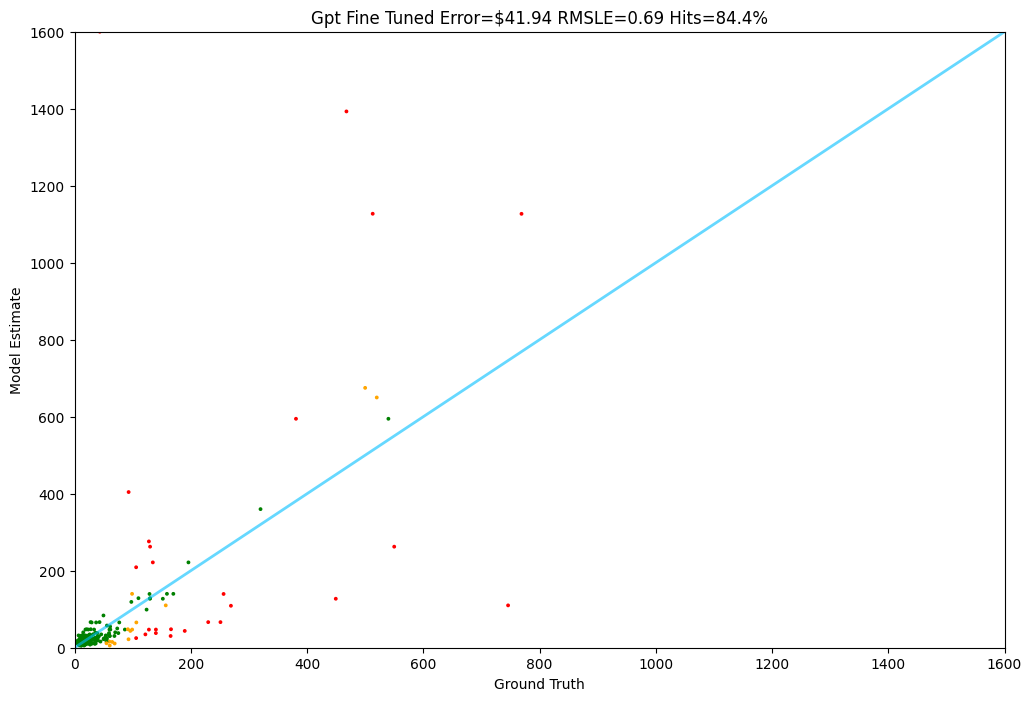

In [ ]:
Tester.test(gpt_fine_tuned, test)